In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import cv2

In [2]:
import sys
import os

# 1. Get the current directory (Minor Project/Notebook)
# 2. Get the parent directory (Minor Project)
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))

# 3. Add that parent directory to sys.path
if root_path not in sys.path:
    sys.path.append(root_path)

In [3]:
from Models.dataloader import CustomDataset,DataLoader

In [4]:
class DepthPredictionHead(nn.Module):
    def __init__(self, in_channels=256, out_channels=1):
        super().__init__()
        # A simple decoder to go from image features to a depth map
        self.decoder = nn.Sequential(
            nn.Conv2d(in_channels, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, out_channels, kernel_size=1),
            nn.Sigmoid() # Normalizes output between 0 and 1
        )

    def forward(self, x):
        return self.decoder(x)

In [5]:
class DepthEncoder(nn.Module):
    def __init__(self,in_channel = 1, embeddings_channel = 256):
        super().__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channel,64,kernel_size=3,padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2,inplace=True)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(64,128,kernel_size=3,padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2,inplace=True)
        )

        self.layer3 = nn.Sequential(
            nn.Conv2d(128,256,kernel_size=3,padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2,inplace=True)
        )

        self.final_projection = nn.Conv2d(256,embeddings_channel,kernel_size=1)


    def forward(self,x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        return self.final_projection(x)

In [6]:
class PositionalEmbeddings(nn.Module):
    def __init__(self,num_tokens = 4096,embedding_dim = 256):
        super().__init__()
        self.pos_embedding = nn.Parameter(torch.randn(1,num_tokens,embedding_dim) * 0.02)

    def forward(self,x):
        return x + self.pos_embedding
    
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=256, nhead=8):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

    def forward(self, x):
        return self.transformer(x)

In [7]:
class DepthSAMFusion(nn.Module):
    def __init__(self):
        super().__init__()

        self.pos_encoder = PositionalEmbeddings()
        self.fusion_transformer = TransformerBlock()

        self.output_conv = nn.Conv2d(256,256,kernel_size=1)

    def forward(self,img_feature,depth_feature):
        # Features has shape [B,256,64,64]
        B,C,H,W = img_feature.shape

        # Flatten should start from dimension 2 and we get result in shape [B,256,4096]
        # then we reshape it to [B,4096,256]
        img_tokens = img_feature.flatten(2).permute(0,2,1)
        depth_tokens = depth_feature.flatten(2).permute(0,2,1)

        img_tokens = self.pos_encoder(img_tokens)
        depth_tokens = self.pos_encoder(depth_tokens)

        fused_tokens = self.fusion_transformer(img_tokens+depth_tokens)

        fused_grid = fused_tokens.permute(0,2,1).reshape(B,C,H,W)

        return self.output_conv(fused_grid)


In [8]:
class DepthSAMFusionModel(nn.Module):
    def __init__(self,sam_model,depth_encoder,fusion_layer):
        self.sam = sam_model
        self.depth_encoder = depth_encoder
        self.fusion_layer = fusion_layer

        for param in self.sam.image_encoder.parameters():
            param.requires_grad = False

    def forward(self,image_input,depth_input):

        with torch.no_grad():
            image_embeddings = self.sam.image_encoder(image_input)

        depth_embeddings = self.depth_encoder(depth_input)

        fused_embeddings = self.fusion_layer(image_embeddings,depth_embeddings)

        sparse_embeddings, dense_embeddings = self.sam.prompt_encoder(
            points=None, boxes=None, masks=None,
        )

        low_res_masks, iou_predictions = self.sam.mask_decoder(
            image_embeddings=fused_embeddings,
            image_pe=self.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False,
        )

        return low_res_masks, iou_predictions

In [9]:
class MonocularSAMModel(nn.Module):
    def __init__(self, sam_model, depth_prediction_head, depth_encoder, fusion_layer):
        super().__init__()
        self.sam = sam_model
        self.depth_head = depth_prediction_head
        self.depth_encoder = depth_encoder
        self.fusion_layer = fusion_layer

        # Freeze SAM's image encoder
        for param in self.sam.image_encoder.parameters():
            param.requires_grad = False

    def forward(self, image_input):
        # 1. Get Image Features
        with torch.no_grad():
            image_embeddings = self.sam.image_encoder(image_input) 

        # 2. Predict Depth
        predicted_depth = self.depth_head(image_embeddings) 
        
        # 3. Encode Depth
        # If you changed in_channel to 1 as discussed, ensure this matches
        depth_embeddings = self.depth_encoder(predicted_depth) 

        # 4. Fusion
        fused_embeddings = self.fusion_layer(image_embeddings, depth_embeddings)

        # 5. Mask Decoding (Task 2)
        sparse_embeddings, dense_embeddings = self.sam.prompt_encoder(
            points=None, boxes=None, masks=None,
        )

        low_res_masks, iou_predictions = self.sam.mask_decoder(
            image_embeddings=fused_embeddings,
            image_pe=self.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False,
        )

        return low_res_masks, predicted_depth

In [10]:
import torch.nn.functional as F

In [11]:
import torch.optim as optim
import torch.nn.functional as F
from segment_anything import SamPredictor,sam_model_registry
model_name = 'vit_b'
model_path = 'D:/Projects/Minor Project/Parameters/SAM-Parameter/sam_vit_b_01ec64.pth'
# 1. Setup Model and Optimizer

sam_model = sam_model_registry[model_name](checkpoint=model_path)
depth_head = DepthPredictionHead()
depth_encoder = DepthEncoder()
fusion_layer = DepthSAMFusion()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MonocularSAMModel(sam_model, depth_head, depth_encoder, fusion_layer).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 2. Define Losses
# Binary Cross Entropy for the Segmentation Mask
criterion_mask = nn.BCEWithLogitsLoss() 
# Mean Squared Error for Depth (only where points exist)
criterion_depth = nn.MSELoss(reduction='none') 

def train_step(batch):
    model.train()
    
    images = batch['image'].to(device)      # [B, 3, 900, 1600]
    gt_masks = batch['gt_mask'].to(device)  # [B, 1, 256, 256]
    gt_depth = batch['gt_depth'].to(device)  # [B, 2, 64, 64]

    images_1024 = F.interpolate(images, (1024, 1024), mode='bilinear', align_corners=False)
    images = images_1024 / 255.0
    
    optimizer.zero_grad()

    # Forward Pass
    pred_masks, pred_depth = model(images) # pred_masks is [B, 1, 256, 256]

    # --- Loss 1: Segmentation ---
    loss_mask = criterion_mask(pred_masks, gt_masks)

    # --- Loss 2: Depth ---
    # Extract depth values and the validity mask
    gt_depth_values = gt_depth[:, 0:1, :, :] # Channel 0
    valid_mask = gt_depth[:, 1:2, :, :]      # Channel 1
    
    # Calculate MSE only for pixels where valid_mask == 1
    depth_error = criterion_depth(pred_depth, gt_depth_values)
    loss_depth = (depth_error * valid_mask).sum() / (valid_mask.sum() + 1e-6)

    # Total Loss (Scaling depth loss helps balance the tasks)
    total_loss = loss_mask + (10.0 * loss_depth)
    
    total_loss.backward()
    optimizer.step()
    
    return total_loss.item(), loss_mask.item(), loss_depth.item()

In [12]:
from nuscenes.utils.geometry_utils import view_points
from nuscenes.nuscenes import NuScenes,NuScenesExplorer
from nuscenes.utils.data_classes import LidarPointCloud
from pyquaternion import Quaternion
import os

data_path = 'D:/Projects/Minor Project/Datasets/raw/nuScenes'

nusc = NuScenes(version='v1.0-mini',dataroot=data_path,verbose=True)
explorer = NuScenesExplorer(nusc)

Loading NuScenes tables for version v1.0-mini...
Loading nuScenes-lidarseg...
32 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
404 lidarseg,
Done loading in 0.388 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


In [13]:
from tqdm import tqdm
dataset = CustomDataset(nusc,explorer,nusc.sample)
dataloader = DataLoader(dataset,batch_size=4,shuffle=True)
num_epochs = 5
for epoch in range(num_epochs):
    loop = tqdm(dataloader, total=len(dataloader), leave=True)
    loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
    
    for batch in loop:
        loss, loss_m, loss_d = train_step(batch)
        
        # Update progress bar with current losses
        loop.set_postfix(total_loss=loss, mask_loss=loss_m, depth_loss=loss_d)

Epoch [5/5]: 100%|██████████| 101/101 [13:33<00:00,  8.05s/it, depth_loss=0.0138, mask_loss=0.0776, total_loss=0.216]


In [31]:
test_image_path = 'D:/Projects/Minor Project/Datasets/raw/testings_images/'
image = cv2.imread(test_image_path + "test1.jpg")
room_img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 1. Resize to 1024x1024 (Crucial for SAM Encoder)
room_img_resized = cv2.resize(room_img, (1024, 1024))

# 2. Convert to Tensor and change shape to [B, C, H, W]
# From [1024, 1024, 3] -> [1, 3, 1024, 1024]
room_tensor = torch.from_numpy(room_img_resized).permute(2, 0, 1).unsqueeze(0).float()

# 3. Scale to 0-1 range
room_tensor = room_tensor / 255.0

# 4. Move to device (cuda or cpu)
room_tensor = room_tensor.to(device)

# 5. Run Inference
model.eval()
with torch.no_grad():
    pred_masks, pred_depth = model(room_tensor)

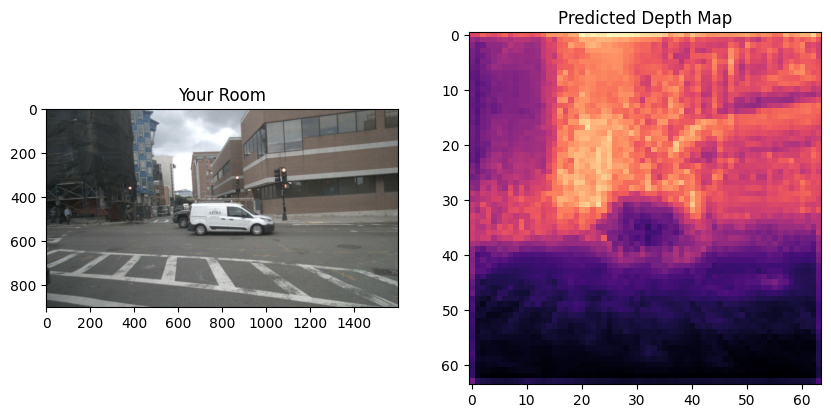

In [32]:
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.imshow(room_img)
plt.title("Your Room")

plt.subplot(1, 2, 2)
# The predicted depth is [1, 1, 64, 64]
plt.imshow(pred_depth.squeeze().cpu().numpy(), cmap='magma')
plt.title("Predicted Depth Map")
plt.show()

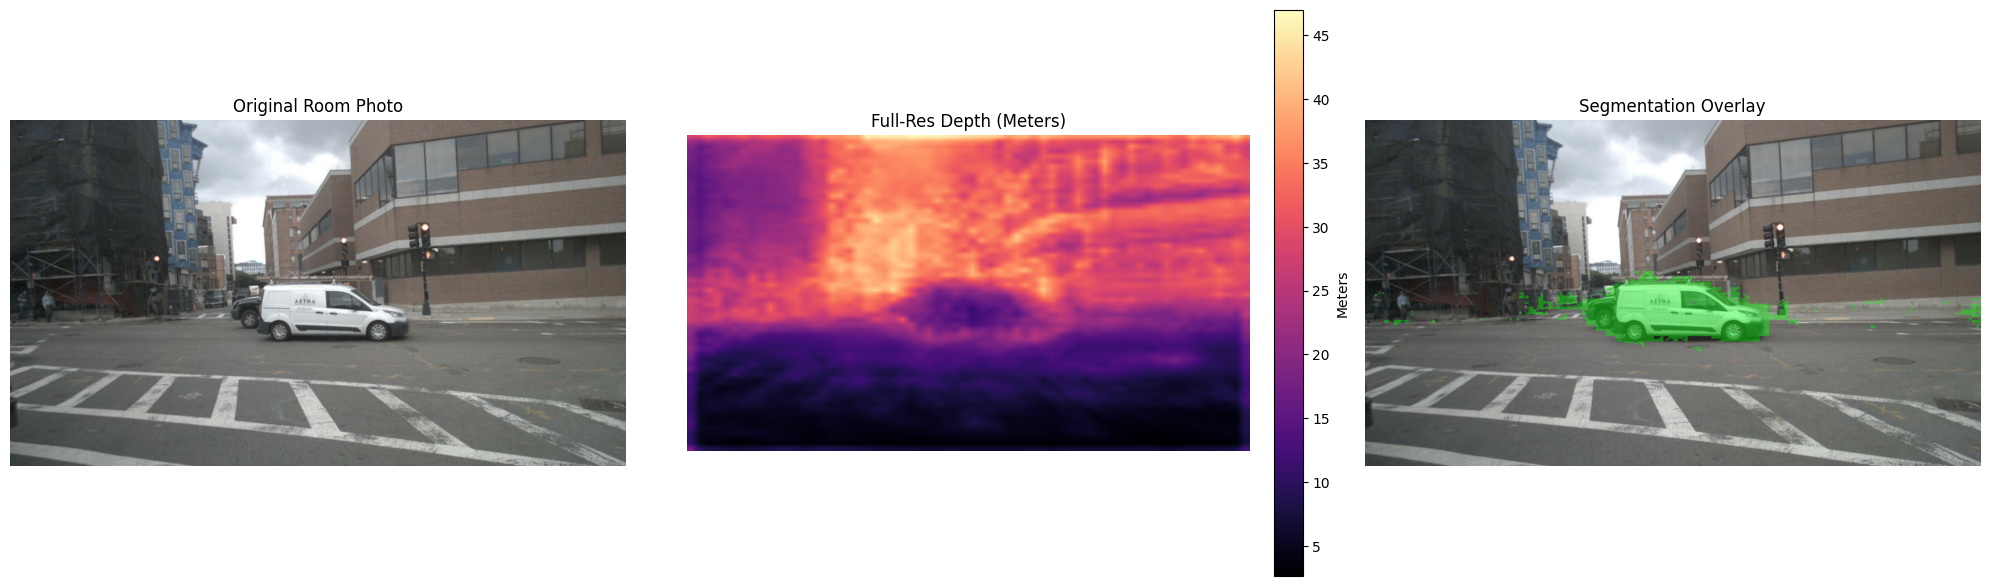

Full-Res Distance to center (450, 800): 19.19 meters


In [33]:
import torch.nn.functional as F

def visualize_results(image_rgb, mask_logits, depth_map, max_dist=80.0):
    """
    image_rgb: Original image [H, W, 3]
    mask_logits: Predicted mask [1, 1, 256, 256]
    depth_map: Predicted depth [1, 1, 64, 64]
    """
    orig_h, orig_w = image_rgb.shape[:2]

    # --- 1. Process Mask ---
    mask_probs = torch.sigmoid(mask_logits).squeeze().cpu().numpy()
    mask_binary = (mask_probs > 0.5).astype(np.uint8)
    mask_resized = cv2.resize(mask_binary, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

    # --- 2. Process Depth Tensor (Full Resolution) ---
    # Upscale 64x64 to original image size
    full_depth_tensor = F.interpolate(
        depth_map, 
        size=(orig_h, orig_w), 
        mode='bilinear', 
        align_corners=False
    )
    
    # De-normalize to meters
    depth_meters_full = (full_depth_tensor.squeeze() * max_dist).cpu().numpy()

    # --- 3. Create Overlay ---
    overlay = image_rgb.copy()
    overlay[mask_resized == 1] = [0, 255, 0] 
    alpha = 0.4
    combined = cv2.addWeighted(overlay, alpha, image_rgb, 1 - alpha, 0)

    # --- 4. Plotting ---
    plt.figure(figsize=(20, 10))
    
    # Original
    plt.subplot(1, 3, 1)
    plt.imshow(image_rgb)
    plt.title("Original Room Photo")
    plt.axis('off')

    # Full-Res Depth Heatmap
    plt.subplot(1, 3, 2)
    im = plt.imshow(depth_meters_full, cmap='magma')
    plt.title("Full-Res Depth (Meters)")
    plt.colorbar(im, fraction=0.046, pad=0.04).set_label('Meters')
    plt.axis('off')

    # Segmentation
    plt.subplot(1, 3, 3)
    plt.imshow(combined)
    plt.title("Segmentation Overlay")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Print center distance using the full-res tensor
    center_h, center_w = orig_h // 2, orig_w // 2
    print(f"Full-Res Distance to center ({center_h}, {center_w}): {depth_meters_full[center_h, center_w]:.2f} meters")

    return depth_meters_full # Returning the full tensor for further use

# Run visualization
full_depth_meters = visualize_results(room_img, pred_masks, pred_depth)

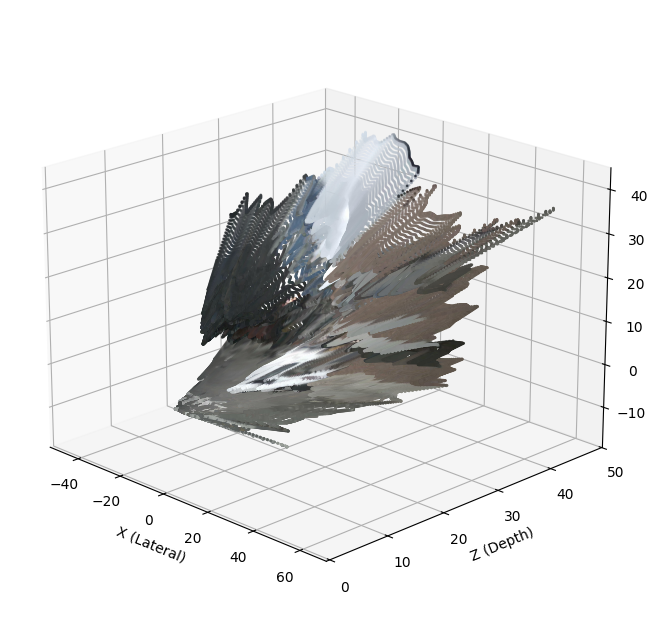

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def create_3d_projection(rgb_image, depth_map, focal_length=518, step=4):
    """
    rgb_image: Original RGB image (numpy array)
    depth_map: Predicted depth map from your model (numpy array)
    focal_length: Estimate if unknown (500-600 is usually safe for standard cameras)
    step: Higher number makes the plot faster by skipping pixels
    """
    h, w = depth_map.shape
    c_x, c_y = w // 2, h // 2
    
    # Create coordinate grid
    u, v = np.meshgrid(np.arange(w), np.arange(h))
    
    # 1. Back-project to 3D coordinates
    z = depth_map
    x = (u - c_x) * z / focal_length
    y = (v - c_y) * z / focal_length
    
    # 2. Flatten and filter (remove points with 0 depth)
    mask = z > 0
    x_pts = x[mask][::step]
    y_pts = y[mask][::step]
    z_pts = z[mask][::step]
    colors = rgb_image[mask][::step] / 255.0  # Normalize colors for matplotlib
    
    # 3. Create the 3D Plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # We swap Y and Z axes to make it look 'grounded'
    ax.scatter(x_pts, z_pts, -y_pts, c=colors, s=1)
    
    ax.set_xlabel('X (Lateral)')
    ax.set_ylabel('Z (Depth)')
    ax.set_zlabel('Y (Height)')
    ax.view_init(elev=20, azim=-45) # Set a good viewing angle
    plt.show()

# --- HOW TO RUN ---
# Assuming 'full_depth_meters' is the output from your visualize_results function
# and 'room_img' is your original image array
create_3d_projection(room_img, full_depth_meters, step=5)